In [81]:

import pandas as pd

hisse_df = pd.read_csv("thyao_veri.csv", index_col=0, parse_dates=True)
print(hisse_df.tail())

                  Open        High         Low       Close    Volume
2024-12-25  282.319516  283.052179  281.098411  281.586853  12283659
2024-12-26  282.807975  286.471291  281.342649  283.296417  27141490
2024-12-27  283.540641  286.471294  283.052199  284.029083  23638402
2024-12-30  284.517544  284.761765  275.725586  275.725586  20734285
2024-12-31  275.969782  279.144655  272.306466  274.504456  26585935


In [82]:

# ── GENEL BİLGİ & İSTATİSTİKLER ────────────────────────────────────────────
print(f"Boyut        : {hisse_df.shape[0]:,} gün  x  {hisse_df.shape[1]} sütun")
print(f"Tarih aralığı: {hisse_df.index[0]}  →  {hisse_df.index[-1]}")
print(f"Eksik değer  : {hisse_df.isnull().sum().sum()}\n")
print("─" * 45)
print(hisse_df.info())


Boyut        : 3,858 gün  x  5 sütun
Tarih aralığı: 2010-01-01 00:00:00  →  2024-12-31 00:00:00
Eksik değer  : 0

─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3858 entries, 2010-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3858 non-null   float64
 1   High    3858 non-null   float64
 2   Low     3858 non-null   float64
 3   Close   3858 non-null   float64
 4   Volume  3858 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 180.8 KB
None


## Görev 1 — Türetilmiş Özellik Mühendisliği (MA5, RSI, Günlük Getiri)

In [83]:
# hisse_df'yi bozmadan kopyasını alıyoruz
model_df = hisse_df.copy()

# ── 1) MA5: Son 5 günün kapanış ortalaması (kısa vadeli trend) ──────────────
model_df['MA5'] = model_df['Close'].rolling(window=5).mean()

# ── 2) RSI (14 günlük) ──────────────────────────────────────────────────────
delta = model_df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
model_df['RSI'] = 100 - (100 / (1 + gain / loss))

# ── 3) Günlük Getiri (%) ────────────────────────────────────────────────────
model_df['Daily_Return'] = model_df['Close'].pct_change() * 100

print(f"Orijinal sütunlar : {list(hisse_df.columns)}")
print(f"Yeni sütunlar     : {list(model_df.columns)}")
print(f"Toplam feature    : {model_df.shape[1]}")
model_df.head(20)


Orijinal sütunlar : ['Open', 'High', 'Low', 'Close', 'Volume']
Yeni sütunlar     : ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'RSI', 'Daily_Return']
Toplam feature    : 8


,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return
2010-01-01,3.442062,3.442062,3.442062,3.442062,0,NaN,NaN,NaN
2010-01-04,3.472522,3.533444,3.350680,3.502983,11846086,NaN,NaN,1.769904
2010-01-05,3.502983,3.533444,3.472522,3.502983,7929532,NaN,NaN,0.000000
2010-01-06,3.502983,3.533444,3.411601,3.472522,9721300,NaN,NaN,-0.869575
2010-01-07,3.411601,3.442062,3.381140,3.411601,7407485,3.466430,NaN,-1.754379
2010-01-08,3.411601,3.442062,3.350680,3.350680,8583119,3.448154,NaN,-1.785693
2010-01-11,3.381140,3.411601,3.259297,3.350680,10830225,3.417693,NaN,0.000000
2010-01-12,3.320219,3.350680,3.228837,3.289758,10073647,3.375048,NaN,-1.818209
2010-01-13,3.289758,3.411601,3.259297,3.411601,13076455,3.362864,NaN,3.703710
2010-01-14,3.472522,3.533444,3.411601,3.472522,20038297,3.375048,NaN,1.785707


In [84]:
#Check if there is any null value in the dataset
model_df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
MA5              4
RSI             14
Daily_Return     1
dtype: int64

## Görev 2 — Hedef (Target) Değişkeni Oluşturma

**Hedef:** Yarınki kapanış bugünkünden yüksek mi?
- `1` → Yükseliş (Yukarı)
- `0` → Düşüş / Yatay (Aşağı)

Hedef Değişken Dağılımı:
  Düşüş    (0): 2,000 gün  (51.9%)
  Yükseliş (1): 1,857 gün  (48.1%)


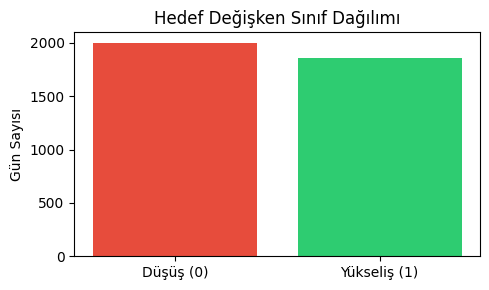

In [85]:
# shift(-1): yarınki kapanışı bugünün satırına getirir
# Eğer yarınki kapanış > bugünkü kapanış → 1, değilse → 0
import matplotlib.pyplot as plt

model_df['Target'] = (model_df['Close'].shift(-1) > model_df['Close']).astype(int)

# Son satırda yarınki veri yok → çıkar
model_df = model_df.iloc[:-1]

counts = model_df['Target'].value_counts()
print("Hedef Değişken Dağılımı:")
print(f"  Düşüş    (0): {counts[0]:,} gün  ({counts[0]/len(model_df)*100:.1f}%)")
print(f"  Yükseliş (1): {counts[1]:,} gün  ({counts[1]/len(model_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Düşüş (0)', 'Yükseliş (1)'], [counts[0], counts[1]],
       color=['#e74c3c', '#2ecc71'])
ax.set_title('Hedef Değişken Sınıf Dağılımı')
ax.set_ylabel('Gün Sayısı')
plt.tight_layout()
plt.show()

In [86]:
model_df['Target'].isnull().sum()  

model_df.tail()

,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return,Target
2024-12-24,279.388863,280.609968,276.702432,278.900421,15485512,281.586865,45.270223,-0.174822,1
2024-12-25,282.319516,283.052179,281.098411,281.586853,12283659,281.147260,42.553165,0.963223,1
2024-12-26,282.807975,286.471291,281.342649,283.296417,27141490,281.244946,32.499997,0.607118,1
2024-12-27,283.540641,286.471294,283.052199,284.029083,23638402,281.440326,34.146344,0.258622,0
2024-12-30,284.517544,284.761765,275.725586,275.725586,20734285,280.707672,27.631618,-2.923467,0


## Görev 3 — Veri Kalitesi Kontrolleri

### 3a. Eksik Değer Analizi

In [87]:
# ── EKSİK DEĞER ANALİZİ ─────────────────────────────────────────────────────
missing_info = model_df.isnull().sum()
missing_pct  = (missing_info / len(model_df) * 100).round(2)
missing_report = pd.DataFrame({'Eksik Sayı': missing_info, 'Eksik %': missing_pct})
missing_report = missing_report[missing_report['Eksik Sayı'] > 0]

print("Eksik değer içeren sütunlar (temizleme öncesi):")
if missing_report.empty:
    print("  → Hiç eksik değer yok.")
else:
    print(missing_report)

print(f"\nTemizleme öncesi satır sayısı: {len(model_df):,}")

# MA5 → ilk 4 satır, RSI → ilk ~14 satır, Daily_Return → ilk 1 satır NaN üretir.
# Bu NaN'lar gösterge pencerelerinin henüz dolmadığı başlangıç günlerinden gelir.
# Doldurmak anlamsız → siliyoruz.
model_df.dropna(inplace=True)

print(f"Temizleme sonrası satır sayısı: {len(model_df):,}")
print(f"Kalan eksik değer: {model_df.isnull().sum().sum()}")

Eksik değer içeren sütunlar (temizleme öncesi):
              Eksik Sayı  Eksik %
MA5                    4     0.10
RSI                   14     0.36
Daily_Return           1     0.03

Temizleme öncesi satır sayısı: 3,857
Temizleme sonrası satır sayısı: 3,843
Kalan eksik değer: 0


### 3b. Borsa Tatil Günü Kontrolü

In [88]:
# ── BORSA TATİL GÜNÜ KONTROLÜ ────────────────────────────────────────────────
# yfinance zaten sadece borsa açık günleri döndürür, ama doğrulayalım.

weekends = model_df[model_df.index.dayofweek >= 5]
print(f"Hafta sonu kayıt sayısı: {len(weekends)}  (0 = tatil günleri doğru şekilde hariç)")

# Ardışık işlem günleri arasındaki boşlukları kontrol et
gaps = model_df.index.to_series().diff().dt.days
large_gaps = gaps[gaps > 4]
print(f"Büyük boşluk (>4 gün) sayısı: {len(large_gaps)} — resmi tatil / bayram dönemleri")

if len(large_gaps) > 0:
    print("\nEn büyük 10 boşluk:")
    print(large_gaps.nlargest(10))

Hafta sonu kayıt sayısı: 0  (0 = tatil günleri doğru şekilde hariç)
Büyük boşluk (>4 gün) sayısı: 10 — resmi tatil / bayram dönemleri

En büyük 10 boşluk:
2023-02-15    7.0
2021-07-26    7.0
2024-04-15    7.0
2024-06-20    6.0
2023-07-03    6.0
2022-05-05    6.0
2020-08-04    5.0
2020-05-27    5.0
2022-07-13    5.0
2021-05-17    5.0
dtype: float64


### 3c. Feature–Target Korelasyon Analizi

Hangi feature'lar hedef değişken (Target) ile en güçlü ilişkiye sahip? Korelasyon haritası ile inceliyoruz.

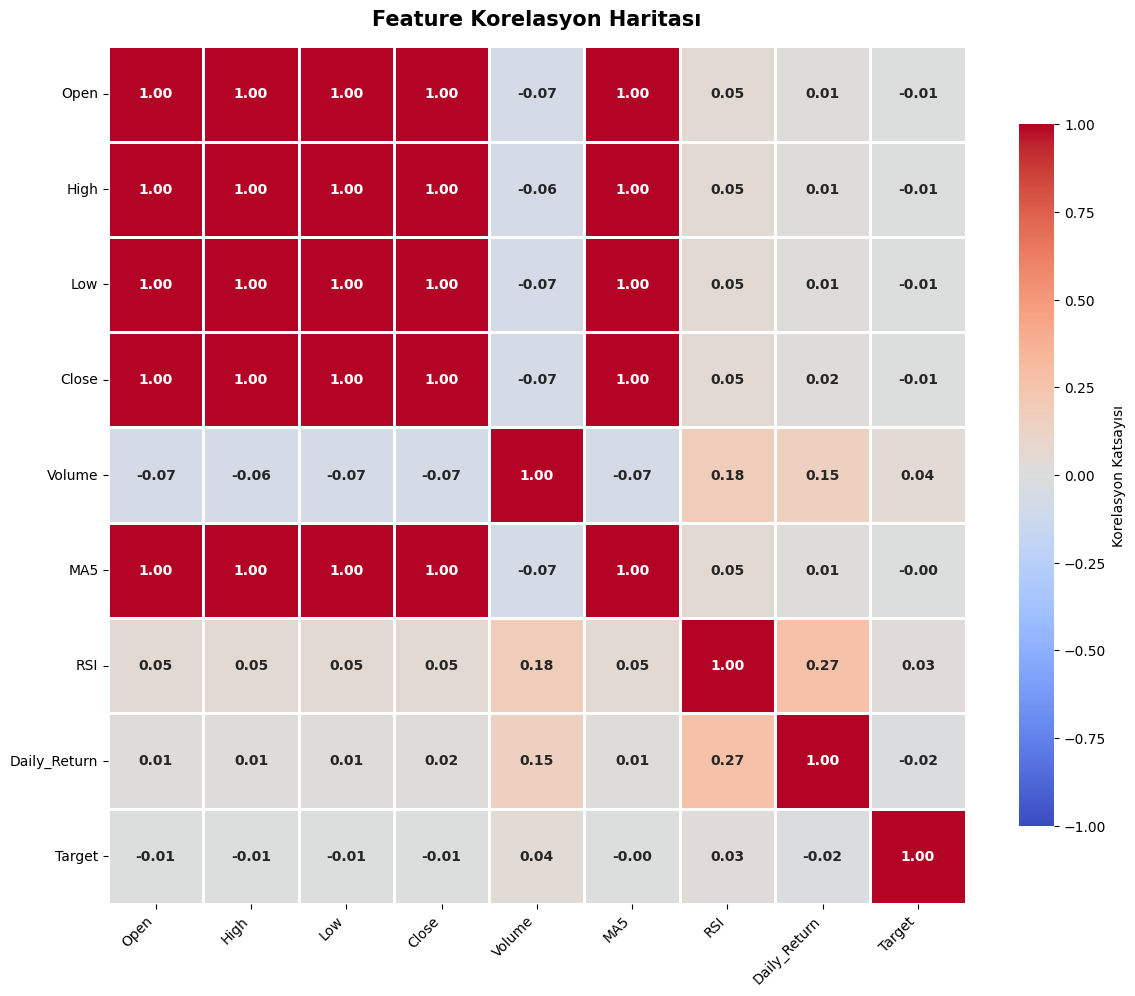

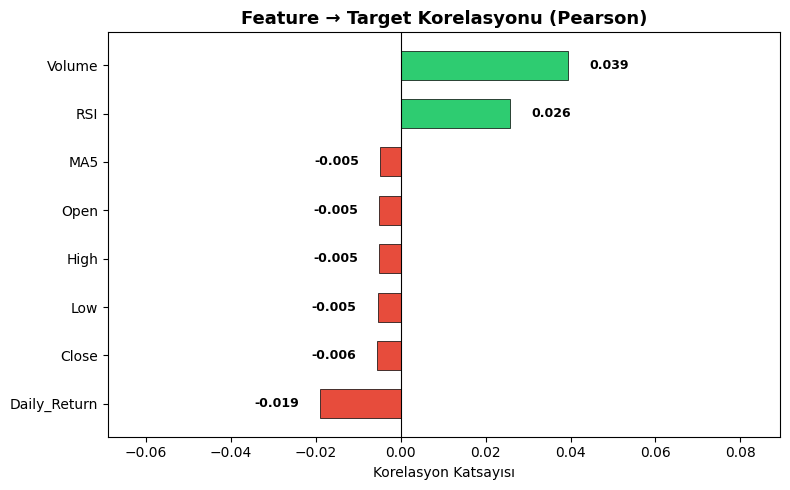

📊 Target ile en yüksek korelasyonlar:
  🟢 Volume          → +0.0394
  🟢 RSI             → +0.0258
  🔴 Daily_Return    → -0.0190
  🔴 Close           → -0.0056
  🔴 Low             → -0.0054
  🔴 High            → -0.0051
  🔴 Open            → -0.0051
  🔴 MA5             → -0.0049


In [89]:
import seaborn as sns
import numpy as np

# ── 1) TÜM FEATURE'LAR ARASI KORELASYON HARİTASI ────────────────────────────
corr_matrix = model_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white',
            annot_kws={'size': 10, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayısı'},
            ax=ax)
ax.set_title('Feature Korelasyon Haritası', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ── 2) TARGET İLE KORELASYON (sıralı bar chart) ─────────────────────────────
target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors,
               edgecolor='black', linewidth=0.5, height=0.6)
ax.set_title('Feature → Target Korelasyonu (Pearson)', fontsize=13, fontweight='bold')
ax.set_xlabel('Korelasyon Katsayısı')
ax.axvline(0, color='black', lw=0.8)

for i, val in enumerate(target_corr.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_xlim(min(target_corr.values) - 0.05, max(target_corr.values) + 0.05)
plt.tight_layout()
plt.show()

print("📊 Target ile en yüksek korelasyonlar:")
for name, val in target_corr.abs().sort_values(ascending=False).items():
    arrow = "🟢" if corr_matrix.loc[name, 'Target'] > 0 else "🔴"
    print(f"  {arrow} {name:15s} → {corr_matrix.loc[name, 'Target']:+.4f}")

## Görev 4 — Model Eğitimi & Değerlendirme

### 4a. Walk-Forward Test Validation Yapısı

**Walk-forward test validation**: Veri karıştırılmadan ilk %80'lik bölüm başlangıç eğitim seti olarak ayrılır. Kalan bölüm ise ardışık test fold'larına bölünür. Her fold'da model yalnızca o ana kadarki geçmiş veriyle yeniden eğitilir ve bir sonraki test bloğu üzerinde değerlendirilir.

**Ayrım yapısı:**

| Bölüm | Tarih Mantığı | Yaklaşık Pay |
|------|----------------|--------------|
| İlk Train | Veri setinin başı → ilk ayrım noktası | %80 |
| Test Fold'ları | Ayrım noktası sonrası ardışık bloklar | %20 |

**Temel ilkeler:**
- Veri zamansal sırayla kullanılır; karıştırma yoktur.
- Her fold'da `MinMaxScaler` yalnızca o fold'un train verisine `fit` edilir.
- Model her fold için sıfırdan yeniden eğitilir.
- Kayan pencere (`20 gün`) LSTM giriş sekansını üretir; walk-forward adım mantığından ayrıdır.
- Tüm fold tahminleri birleştirilerek confusion matrix ve toplu metrikler hesaplanır.

Toplam veri        : 3,843 gün
İlk train seti     : 3,074 gün  (80%)
  Tarih aralığı    : 2010-01-21 → 2021-12-03
Walk-forward test  : 769 gün  (20%)
  Tarih aralığı    : 2021-12-06 → 2024-12-30
Fold sayısı        : 37
Fold test boyutu   : ~21 gün


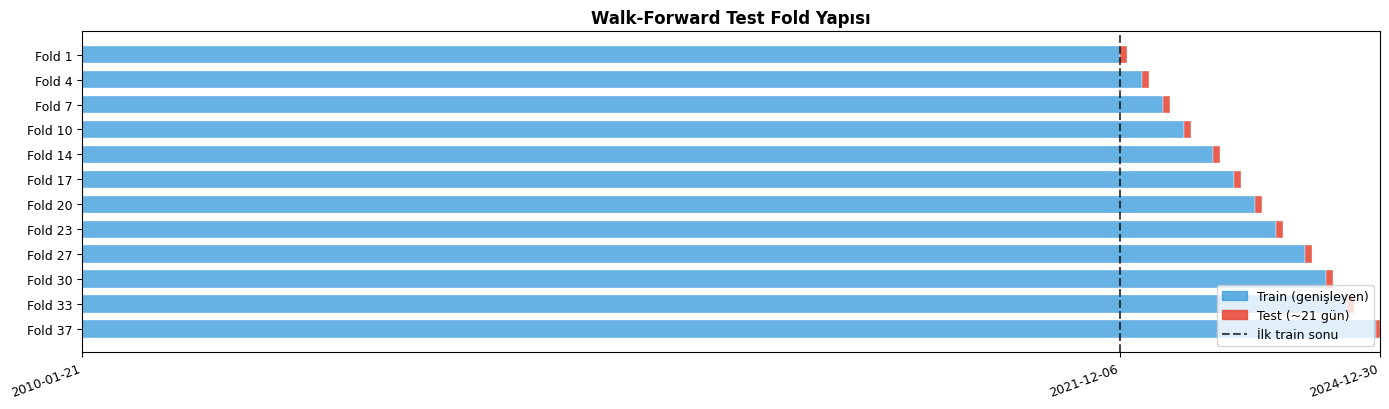

            Bölüm  Başlangıç      Bitiş  Gün Sayısı  Oran
        İlk Train 2010-01-21 2021-12-03        3074 80.0%
Walk-Forward Test 2021-12-06 2024-12-30         769 20.0%

İlk train tensörü: (3074, 4)  |  Ayrılan test: (769, 4)
Feature'lar: ['Close', 'Volume', 'RSI', 'Daily_Return']


In [90]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patches as mpatches

# ── FEATURE / TARGET AYIRMA ─────────────────────────────────────────────────
DROPPED_FEATURES = ['Open', 'High', 'Low', 'MA5']
FEATURE_COLS = [
    col for col in model_df.columns
    if col not in DROPPED_FEATURES + ['Target']
]
X = model_df[FEATURE_COLS].values
y = model_df['Target'].values

# ── WALK-FORWARD TEST FOLD TANIMI ───────────────────────────────────────────
TRAIN_RATIO = 0.80
split_idx = int(len(X) * TRAIN_RATIO)
WF_TEST_DAYS = 21

if split_idx <= 20 or split_idx >= len(X):
    raise ValueError("Geçerli bir train/test ayrımı için veri boyutu yetersiz.")

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train     = y[:split_idx]
y_test      = y[split_idx:]

train_start_date = model_df.index[0].date()
train_end_date   = model_df.index[split_idx - 1].date()
test_start_date  = model_df.index[split_idx].date()
test_end_date    = model_df.index[-1].date()

wf_test_indices = []
cursor = split_idx
while cursor < len(X):
    fold_end = min(cursor + WF_TEST_DAYS, len(X))
    wf_test_indices.append(np.arange(cursor, fold_end))
    cursor = fold_end

WF_N_SPLITS = len(wf_test_indices)
WF_STEP_DAYS = WF_TEST_DAYS

print(f"Toplam veri        : {len(X):,} gün")
print(f"İlk train seti     : {len(X_train_raw):,} gün  ({TRAIN_RATIO:.0%})")
print(f"  Tarih aralığı    : {train_start_date} → {train_end_date}")
print(f"Walk-forward test  : {len(X_test_raw):,} gün  ({1 - TRAIN_RATIO:.0%})")
print(f"  Tarih aralığı    : {test_start_date} → {test_end_date}")
print(f"Fold sayısı        : {WF_N_SPLITS}")
print(f"Fold test boyutu   : ~{WF_TEST_DAYS} gün")

# ── WALK-FORWARD YAPI GÖRSELİ ───────────────────────────────────────────────
train_c, test_c = '#3498db', '#e74c3c'
n_disp = min(12, WF_N_SPLITS)
disp_idx = np.linspace(0, WF_N_SPLITS - 1, n_disp, dtype=int) if WF_N_SPLITS > 1 else np.array([0])

fig, ax = plt.subplots(figsize=(14, 4.2))
for row_pos, fold_idx in enumerate(reversed(disp_idx)):
    fold_indices = wf_test_indices[fold_idx]
    fold_start = int(fold_indices[0])
    fold_end = int(fold_indices[-1]) + 1
    ax.barh(row_pos, fold_start, left=0, height=0.7, color=train_c, alpha=0.75, ec='white', lw=0.3)
    ax.barh(row_pos, fold_end - fold_start, left=fold_start, height=0.7, color=test_c, alpha=0.9, ec='white', lw=0.3)

ax.set_yticks(range(len(disp_idx)))
ax.set_yticklabels([f'Fold {disp_idx[len(disp_idx) - 1 - i] + 1}' for i in range(len(disp_idx))], fontsize=9)

tick_pos = [0, split_idx, len(X) - 1]
tick_lbl = [
    str(model_df.index[0].date()),
    str(model_df.index[split_idx].date()),
    str(model_df.index[-1].date()),
]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=20, ha='right', fontsize=9)
ax.axvline(split_idx, color='black', ls='--', lw=1.5, alpha=0.7, label='İlk train sonu')
ax.set_xlim(0, len(X))
ax.set_title('Walk-Forward Test Fold Yapısı', fontweight='bold', fontsize=12)
train_p = mpatches.Patch(color=train_c, alpha=0.75, label='Train (genişleyen)')
test_p  = mpatches.Patch(color=test_c, alpha=0.90, label=f'Test (~{WF_TEST_DAYS} gün)')
ax.legend(handles=[train_p, test_p, ax.get_lines()[0]], fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(
    {
        'Bölüm': ['İlk Train', 'Walk-Forward Test'],
        'Başlangıç': [train_start_date, test_start_date],
        'Bitiş': [train_end_date, test_end_date],
        'Gün Sayısı': [len(X_train_raw), len(X_test_raw)],
        'Oran': [f'{len(X_train_raw) / len(X):.1%}', f'{len(X_test_raw) / len(X):.1%}'],
    }
)
print(summary_df.to_string(index=False))

# İlk train bloğunu yalnızca keşif/görselleştirme hücreleri için ölçekliyoruz.
initial_scaler = MinMaxScaler()
X_train = initial_scaler.fit_transform(X_train_raw)
X_test  = initial_scaler.transform(X_test_raw)
X_all_scaled = initial_scaler.transform(X)
scaler  = initial_scaler

print(f"\nİlk train tensörü: {X_train.shape}  |  Ayrılan test: {X_test.shape}")
print(f"Feature'lar: {FEATURE_COLS}")

### 4a-1. Eğitim Seti Feature Dağılımları 


Her feature'ın dağılımını histogram + KDE ile inceliyoruz. Çarpık (skewed) veya çok uç değerli dağılımlar modeli olumsuz etkileyebilir.

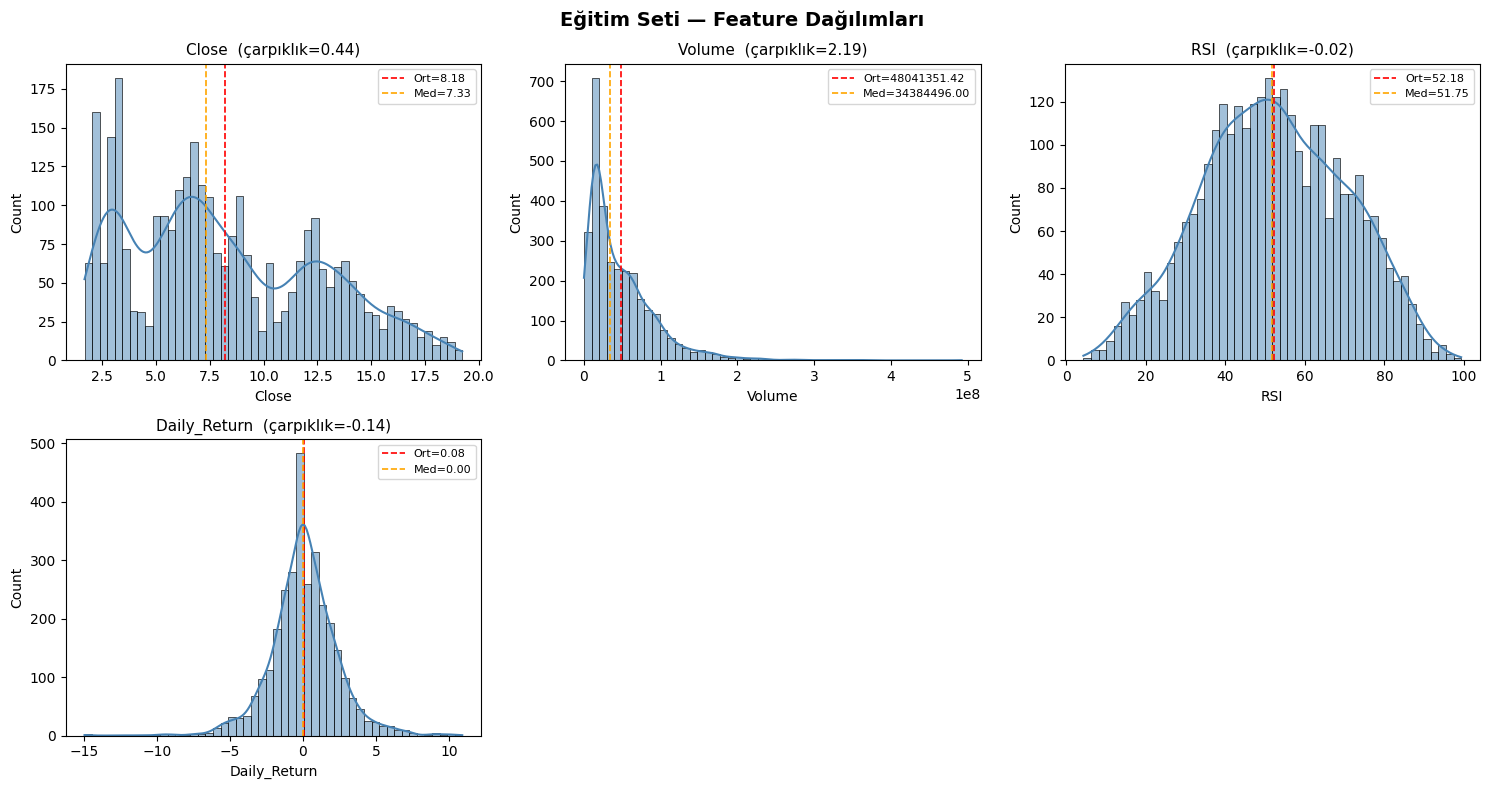


📊 Eğitim Seti İstatistik Özeti:


,mean,50%,std,min,max,skew,kurtosis
Close,8.181100e+00,7.331500e+00,4.380900e+00,1.6711,1.923490e+01,0.4402,-0.7878
Volume,4.804135e+07,3.438450e+07,4.491994e+07,0.0000,4.921997e+08,2.1856,8.6511
RSI,5.217590e+01,5.175060e+01,1.798420e+01,4.2618,9.931660e+01,-0.0224,-0.5672
Daily_Return,8.080000e-02,0.000000e+00,2.299900e+00,-14.9448,1.089740e+01,-0.1407,3.1780


In [91]:
import seaborn as sns

train_df = pd.DataFrame(X_train_raw, columns=FEATURE_COLS)

n_cols = 3
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    sns.histplot(train_df[col], kde=True, ax=ax, color='steelblue', bins=50)
    
    # İstatistikler
    mean = train_df[col].mean()
    med  = train_df[col].median()
    skew = train_df[col].skew()
    
    ax.axvline(mean, color='red', ls='--', lw=1.2, label=f'Ort={mean:.2f}')
    ax.axvline(med,  color='orange', ls='--', lw=1.2, label=f'Med={med:.2f}')
    ax.set_title(f'{col}  (çarpıklık={skew:.2f})', fontsize=11)
    ax.legend(fontsize=8)

# Boş grafikleri gizle
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Eğitim Seti — Feature Dağılımları ', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── ÖZET TABLO ────────────────────────────────────────────────────────────────
desc = train_df.describe().T
desc['skew'] = train_df.skew()
desc['kurtosis'] = train_df.kurtosis()
print("\n📊 Eğitim Seti İstatistik Özeti:")
desc[['mean', '50%', 'std', 'min', 'max', 'skew', 'kurtosis']].round(4)

In [92]:
X_train

array([[0.09563019, 0.01936093, 0.40603284, 0.50920999],
       [0.09216156, 0.01378981, 0.30583979, 0.50795172],
       [0.09216156, 0.00959235, 0.30583979, 0.57830966],
       ...,
       [0.92880733, 0.3878125 , 0.53236883, 0.84572312],
       [0.91990826, 0.24664519, 0.51281151, 0.544679  ],
       [0.93548161, 0.37594468, 0.5482036 , 0.63767921]], shape=(3074, 4))

### 4b. LSTM — Kayan Pencere & Model

- **Kayan pencere = 20 gün:** Her örneklem `(20, n_features)` boyutunda tensör.
- **Dropout:** Aşırı öğrenmeyi önler.
- **EarlyStopping:** val_loss 10 epoch boyunca iyileşmezse durur, en iyi ağırlıkları geri yükler.

In [93]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# ── KAYAN PENCERE (SEKANS ÜRETİCİLER) ────────────────────────────────────────
WINDOW = 20

def create_sequences(X, y, window):
    """
    Train sekansları: X[i : i+window] → y[i+window-1]
    Pencere: i. günden (i+window-1). güne kadar (window gün).
    Hedef  : y[i+window-1] = (Close[i+window] > Close[i+window-1])
             → bugünkü (i+window-1) kapanışa göre yarın yükselecek mi?
    """
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i + window])
        ys.append(y[i + window - 1])
    return np.array(Xs), np.array(ys)

def create_eval_sequences(X_scaled, y, start_idx, end_idx, window):
    """
    Walk-forward test sekansları.
    Her target_idx için [target_idx-window+1 : target_idx+1] bağlam penceresi alınır.
    Böylece test fold'unun ilk örneği bile train döneminin son günlerini bağlam olarak kullanabilir.
    Gelecek veri kullanılmaz; her tahmin yalnızca o güne kadar olan gözlemlere dayanır.
    """
    Xs, ys, target_indices = [], [], []
    for target_idx in range(start_idx, end_idx):
        Xs.append(X_scaled[target_idx - window + 1 : target_idx + 1])
        ys.append(y[target_idx])
        target_indices.append(target_idx)
    return np.array(Xs), np.array(ys), np.array(target_indices)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW)

print(f"İlk train sekansları : {X_train_seq.shape}  (örneklem, pencere, feature)")
print(f"Walk-forward fold    : {WF_N_SPLITS}")
print(f"Toplam test günü     : {sum(len(fold) for fold in wf_test_indices):,}")

İlk train sekansları : (3054, 20, 4)  (örneklem, pencere, feature)
Walk-forward fold    : 37
Toplam test günü     : 769


In [94]:
# Hyperparameters of Model

hyperparams = {
    "window": WINDOW,
    "epochs": 50,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss_function": "binary_crossentropy",
    "early_stopping_patience": 10,
    "reduce_lr_patience": 8,
    "reduce_lr_factor": 0.5,
    "dropout_rates": 0.2,
    "lstm_units": 64,
    "dense_units": 16,
    "evaluation_method": "walk_forward",
    "train_ratio": TRAIN_RATIO,
    "wf_test_days": WF_TEST_DAYS,
    "wf_step_days": WF_STEP_DAYS,
    "walk_forward_splits": WF_N_SPLITS,
    "validation_split": 0.15,
    "shuffle": False,
    "train_samples": len(X_train_seq),
    "backtest_samples": int(sum(len(fold) for fold in wf_test_indices)),
}


In [95]:

# ── LSTM MODEL ŞABLONU ───────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

n_features = X_train_seq.shape[2]

def build_lstm_model(hyperparams, n_features):
    model = Sequential([
        Input(shape=(hyperparams["window"], n_features)),
        LSTM(hyperparams["lstm_units"], return_sequences=True),
        Dropout(hyperparams["dropout_rates"]),
        LSTM(hyperparams["lstm_units"], return_sequences=False),
        Dropout(hyperparams["dropout_rates"]),
        Dense(hyperparams["dense_units"], activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=hyperparams["learning_rate"]),
        loss=hyperparams["loss_function"],
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(hyperparams, n_features)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,745 (202.13 KB)

 Trainable params: 51,745 (202.13 KB)

 Non-trainable params: 0 (0.00 B)

### 4c. Walk-Forward Model Eğitimi, Confusion Matrix ve Sınıflandırma Metrikleri

Bu bölümde LSTM modeli her walk-forward fold için yalnızca geçmiş verilerle yeniden eğitilir. Her fold'un test tahminleri birleştirilir; ardından confusion matrix ve toplu sınıflandırma metrikleri hesaplanır.

In [96]:
# DEFINITION OF CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=hyperparams['early_stopping_patience'],
    restore_best_weights=True,
    verbose=1,
    mode='min',
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=hyperparams['reduce_lr_factor'],
    patience=hyperparams['reduce_lr_patience'],
    min_lr=1e-5,
    verbose=1,
    mode='min',
)


In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    log_loss,
    average_precision_score,
    precision_recall_fscore_support,
    
 )
from tensorflow.keras import backend as K

def create_callbacks(hyperparams):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=hyperparams['early_stopping_patience'],
        restore_best_weights=True,
        verbose=0,
        mode='min',
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=hyperparams['reduce_lr_factor'],
        patience=hyperparams['reduce_lr_patience'],
        min_lr=1e-5,
        verbose=1,
        mode='min',
    )
    return [early_stop, reduce_lr]

def walk_forward_lstm(X_raw, y, dates, test_folds, window, hyperparams):
    fold_summaries = []
    prob_batches = []
    pred_batches = []
    true_batches = []
    pred_index_batches = []
    last_history = None
    last_model = None

    for fold_no, fold_indices in enumerate(test_folds, start=1):
        train_end = int(fold_indices[0])
        test_end = int(fold_indices[-1]) + 1

        fold_scaler = MinMaxScaler()
        X_train_fold = fold_scaler.fit_transform(X_raw[:train_end])
        X_eval_fold = fold_scaler.transform(X_raw[:test_end])
        y_train_fold = y[:train_end]

        X_tr_seq, y_tr_seq = create_sequences(X_train_fold, y_train_fold, window)
        X_te_seq, y_te_seq, fold_target_idx = create_eval_sequences(
            X_eval_fold, y, train_end, test_end, window
        )

        if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
            raise ValueError(f"Fold {fold_no} için yeterli sekans üretilemedi.")

        classes = np.unique(y_tr_seq)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_tr_seq,
        )
        class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights)}

        K.clear_session()
        fold_model = build_lstm_model(hyperparams, X_tr_seq.shape[2])
        
        fold_history = fold_model.fit(
            X_tr_seq,
            y_tr_seq,
            validation_split=hyperparams['validation_split'],
            epochs=hyperparams['epochs'],
            batch_size=hyperparams['batch_size'],
            shuffle=hyperparams['shuffle'],
            callbacks=create_callbacks(hyperparams),
            class_weight=class_weight_dict,
            verbose=1,
        )

        fold_prob = fold_model.predict(X_te_seq, verbose=0).ravel()
        fold_pred = (fold_prob >= 0.5).astype(int)

        fold_accuracy = accuracy_score(y_te_seq, fold_pred)
        fold_precision = precision_score(y_te_seq, fold_pred, zero_division=0)
        fold_recall = recall_score(y_te_seq, fold_pred, zero_division=0)
        fold_f1 = f1_score(y_te_seq, fold_pred, zero_division=0)

        try:
            fold_roc_auc = roc_auc_score(y_te_seq, fold_prob)
        except ValueError:
            fold_roc_auc = np.nan

        fold_summaries.append(
            {
                'fold': fold_no,
                'train_end_idx': train_end - 1,
                'test_start_idx': int(fold_indices[0]),
                'test_end_idx': int(fold_indices[-1]),
                'train_end_date': str(dates[train_end - 1].date()),
                'test_start_date': str(dates[int(fold_indices[0])].date()),
                'test_end_date': str(dates[int(fold_indices[-1])].date()),
                'train_samples': int(len(X_tr_seq)),
                'test_samples': int(len(X_te_seq)),
                'accuracy': float(fold_accuracy),
                'precision': float(fold_precision),
                'recall': float(fold_recall),
                'f1_score': float(fold_f1),
                'roc_auc': float(fold_roc_auc) if not np.isnan(fold_roc_auc) else None,
                'best_val_loss': float(np.min(fold_history.history['val_loss'])),
                'epochs_ran': int(len(fold_history.history['loss'])),
            }
        )

        prob_batches.append(fold_prob)
        pred_batches.append(fold_pred)
        true_batches.append(y_te_seq)
        pred_index_batches.append(fold_target_idx)
        last_history = fold_history
        last_model = fold_model

    return {
        'fold_results': pd.DataFrame(fold_summaries),
        'y_prob': np.concatenate(prob_batches),
        'y_pred': np.concatenate(pred_batches),
        'y_true': np.concatenate(true_batches),
        'pred_indices': np.concatenate(pred_index_batches),
        'last_history': last_history,
        'last_model': last_model,
        'class_weight_dict': class_weight_dict,
    }

walk_forward_results = walk_forward_lstm(
    X_raw=X,
    y=y,
    dates=model_df.index,
    test_folds=wf_test_indices,
    window=WINDOW,
    hyperparams=hyperparams,
)

fold_results = walk_forward_results['fold_results']
y_prob = walk_forward_results['y_prob']
y_pred = walk_forward_results['y_pred']
y_test_seq = walk_forward_results['y_true']
pred_indices = walk_forward_results['pred_indices']
history = walk_forward_results['last_history']
trained_model = walk_forward_results['last_model']
class_weight_dict = walk_forward_results['class_weight_dict']

accuracy = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, zero_division=0)
recall = recall_score(y_test_seq, y_pred, zero_division=0)
f1 = f1_score(y_test_seq, y_pred, zero_division=0)
balanced_acc = balanced_accuracy_score(y_test_seq, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_seq, y_pred).ravel()

try:
    roc_auc = roc_auc_score(y_test_seq, y_prob)
except ValueError:
    roc_auc = float('nan')

try:
    pr_auc = average_precision_score(y_test_seq, y_prob)
except ValueError:
    pr_auc = float('nan')

test_loss = log_loss(y_test_seq, y_prob, labels=[0, 1])

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_seq, y_pred, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test_seq, y_pred, average='weighted', zero_division=0
)

metrics_summary = {
    'evaluation_method': 'walk_forward',
    'train_ratio': float(TRAIN_RATIO),
    'window': int(WINDOW),
    'walk_forward_splits': int(WF_N_SPLITS),
    'wf_test_days': int(WF_TEST_DAYS),
    'evaluated_samples': int(len(y_test_seq)),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'balanced_accuracy': float(balanced_acc),
    'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else None,
    'pr_auc': float(pr_auc) if not np.isnan(pr_auc) else None,
    'log_loss': float(test_loss),
    'tn': int(tn),
    'fp': int(fp),
    'fn': int(fn),
    'tp': int(tp),
    'train_start': str(train_start_date),
    'initial_train_end': str(train_end_date),
    'test_start': str(test_start_date),
    'test_end': str(test_end_date),
}

print('Walk-forward sınıflandırma raporu:')
print(classification_report(y_test_seq, y_pred, digits=4, zero_division=0))

display(fold_results.round(4))

metrics_table = pd.DataFrame(
    {
        'Metrik': [
            'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Balanced Accuracy',
            'ROC AUC', 'PR AUC'
        ],
        'Değer': [
            accuracy, precision, recall, f1, balanced_acc,
            roc_auc, pr_auc
        ],
    }
)
display(metrics_table.round(4))

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5094 - loss: 0.6945 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5252 - loss: 0.6930 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5102 - loss: 0.6932 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5110 - loss: 0.6934 - val_accuracy: 0.5054 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5168 - loss: 0.6939 - val_accuracy: 0.5054 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5106 - loss: 0.6942 - val_accuracy: 0.5054 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5272 - loss: 0.6936 - val_acc

,fold,train_end_idx,test_start_idx,test_end_idx,train_end_date,test_start_date,test_end_date,train_samples,test_samples,accuracy,precision,recall,f1_score,roc_auc,best_val_loss,epochs_ran
0,1,3073,3074,3094,2021-12-03,2021-12-06,2022-01-03,3054,21,0.4286,0.0000,0.0000,0.0000,0.6574,0.6928,20
1,2,3094,3095,3115,2022-01-03,2022-01-04,2022-02-01,3075,21,0.3810,0.0000,0.0000,0.0000,0.7115,0.6926,14
2,3,3115,3116,3136,2022-02-01,2022-02-02,2022-03-02,3096,21,0.6190,0.0000,0.0000,0.0000,0.4904,0.6931,11
3,4,3136,3137,3157,2022-03-02,2022-03-03,2022-03-31,3117,21,0.2381,0.0000,0.0000,0.0000,0.5875,0.6931,17
4,5,3157,3158,3178,2022-03-31,2022-04-01,2022-04-29,3138,21,0.6667,0.6667,1.0000,0.8000,0.3776,0.6932,12
5,6,3178,3179,3199,2022-04-29,2022-05-05,2022-06-03,3159,21,0.4286,0.0000,0.0000,0.0000,0.2222,0.6934,11
6,7,3199,3200,3220,2022-06-03,2022-06-06,2022-07-04,3180,21,0.4762,0.4762,1.0000,0.6452,0.4909,0.6929,13
7,8,3220,3221,3241,2022-07-04,2022-07-05,2022-08-05,3201,21,0.2857,0.0000,0.0000,0.0000,0.5111,0.6932,11
8,9,3241,3242,3262,2022-08-05,2022-08-08,2022-09-06,3222,21,0.2857,0.0000,0.0000,0.0000,0.4833,0.6941,12
9,10,3262,3263,3283,2022-09-06,2022-09-07,2022-10-05,3243,21,0.5238,0.0000,0.0000,0.0000,0.4455,0.6947,12


,Metrik,Değer
0,Accuracy,0.4902
1,Precision,0.5270
2,Recall,0.0985
3,F1 Score,0.1660
4,Balanced Accuracy,0.5023
5,ROC AUC,0.4880
6,PR AUC,0.5128


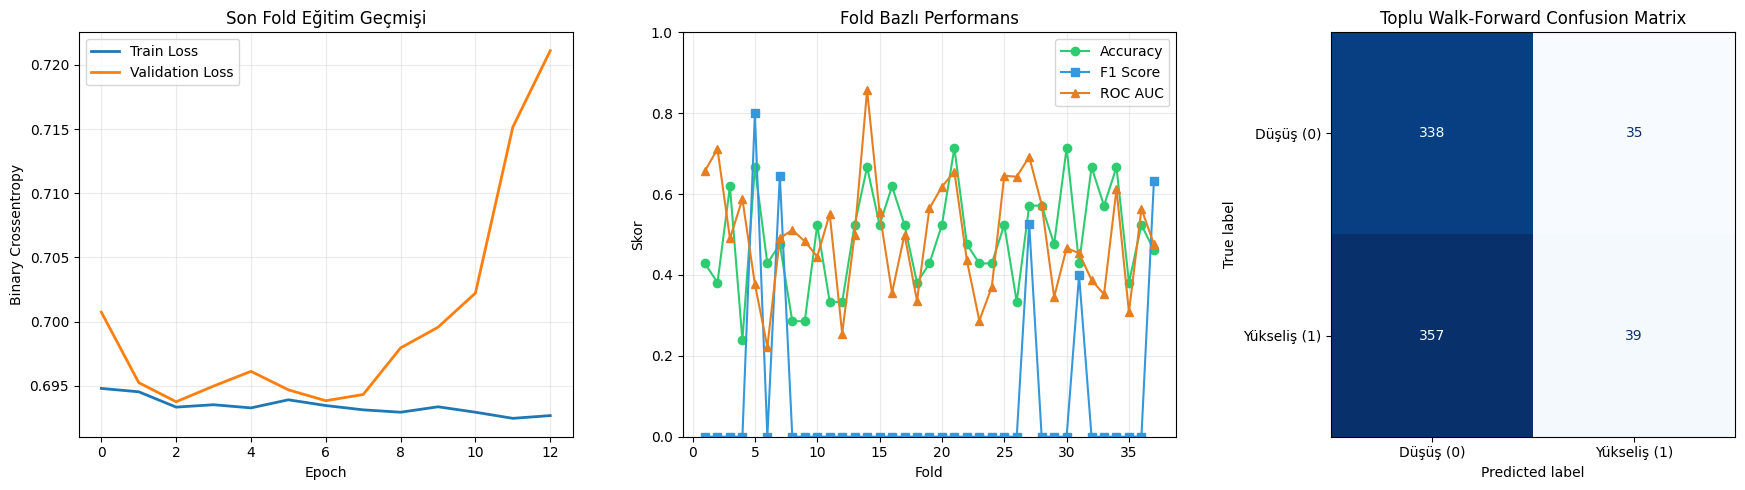

In [98]:
# Walk-forward fold metrikleri ve confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
axes[0].set_title('Son Fold Eğitim Geçmişi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(fold_results['fold'], fold_results['accuracy'], marker='o', label='Accuracy', color='#2ecc71')
axes[1].plot(fold_results['fold'], fold_results['f1_score'], marker='s', label='F1 Score', color='#3498db')
if fold_results['roc_auc'].notna().any():
    axes[1].plot(fold_results['fold'], fold_results['roc_auc'], marker='^', label='ROC AUC', color='#e67e22')
axes[1].set_title('Fold Bazlı Performans')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Skor')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

cm = confusion_matrix(y_test_seq, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Düşüş (0)', 'Yükseliş (1)'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Toplu Walk-Forward Confusion Matrix')

plt.tight_layout()
plt.show()

### 4d. Walk-Forward Log Kaydı

Bu hücre, walk-forward eğitim tamamlandıktan sonra hipermetreleri, toplu metrikleri, fold bazlı sonuçları ve model özetini zaman damgalı bir klasöre kaydeder.

In [99]:
import io
import json
import os
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = os.path.join('logs', timestamp)
os.makedirs(log_dir, exist_ok=True)

hyperparams_to_save = {
    **hyperparams,
    'train_start': str(train_start_date),
    'initial_train_end': str(train_end_date),
    'test_start': str(test_start_date),
    'test_end': str(test_end_date),
    'class_weight_strategy': 'balanced',
    'class_weights': {str(k): float(v) for k, v in class_weight_dict.items()},
}

with open(os.path.join(log_dir, 'hyperparameters.json'), 'w', encoding='utf-8') as f:
    json.dump(hyperparams_to_save, f, ensure_ascii=False, indent=2)

with open(os.path.join(log_dir, 'metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

with open(os.path.join(log_dir, 'walk_forward_folds.json'), 'w', encoding='utf-8') as f:
    json.dump(fold_results.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

model_summary_buffer = io.StringIO()
trained_model.summary(print_fn=lambda line: model_summary_buffer.write(line + '\n'))
with open(os.path.join(log_dir, 'model_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(model_summary_buffer.getvalue())


print('Walk-forward log kayıtları oluşturuldu:')
print(f'  Klasör: {log_dir}')
print('  Dosyalar:')
print('   - hyperparameters.json')
print('   - metrics.json')
print('   - walk_forward_folds.json')
print('   - model_summary.txt')


Walk-forward log kayıtları oluşturuldu:
  Klasör: logs\20260423_161828
  Dosyalar:
   - hyperparameters.json
   - metrics.json
   - walk_forward_folds.json
   - model_summary.txt
